### **Operador XOR**

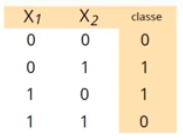

In [4]:
import numpy as np
from keras import layers, models

# **Construindo o Modelo**

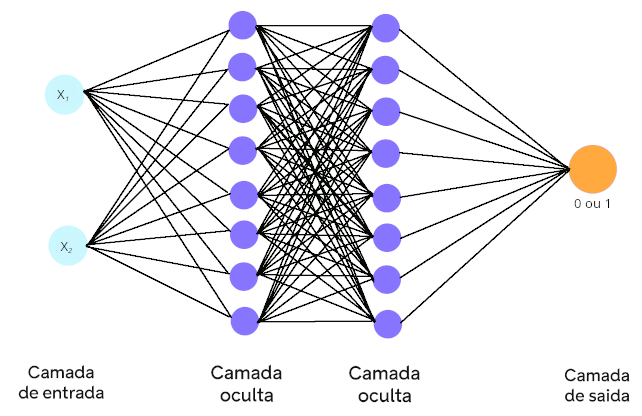


In [28]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

model = models.Sequential()
model.add(layers.Input(shape=(2,), name='input_layer'))
model.add(layers.Dense(8, activation='tanh', name='hidden_layer_1'))
model.add(layers.Dense(8, activation='tanh', name='hidden_layer_2'))
model.add(layers.Dense(1, activation='sigmoid', name='output_layer'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# model.fit(X, y, epochs=800, verbose=1) # Puxa mais pro overfitting, mas é o suficiente para aprender a função XOR
# model.fit(X, y, epochs=400, verbose=1) # Puxa mais pro underfitting, mas é o suficiente para aprender a função XOR
model.fit(X, y, epochs=600, verbose=1) # Puxa mais pro meio termo, mas é o suficiente para aprender a função XOR

Epoch 1/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step - accuracy: 0.7500 - loss: 0.7022
Epoch 2/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.7009
Epoch 3/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6997
Epoch 4/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6985
Epoch 5/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 0.6974
Epoch 6/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.6964
Epoch 7/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5000 - loss: 0.6954
Epoch 8/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 0.6945
Epoch 9/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.6936
Epoch 10/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6928
Epoch 11/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.6920
Epoch 12/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - l

In [30]:
loss, accuracy = model.evaluate(X, y, verbose=2)

1/1 - 0s - 99ms/step - accuracy: 1.0000 - loss: 0.0669


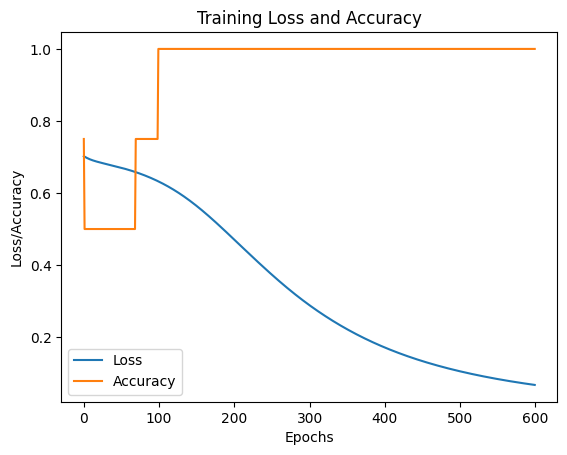

In [31]:
from matplotlib import pyplot as plt

plt.plot(model.history.history['loss'], label='Loss')
plt.plot(model.history.history['accuracy'], label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.title('Training Loss and Accuracy')
plt.legend()
plt.show()

In [32]:
predictions = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predictions:
[[0.03251523]
 [0.8908227 ]
 [0.95430887]
 [0.06958946]]


In [37]:
for i in range(len(predictions)):
    print(f'XOR: {X[i]} - Predicted: {1 if predictions[i][0] > 0.5 else 0} - Actual: {y[i][0]:0.0f}')

XOR: [0. 0.] - Predicted: 0 - Actual: 0
XOR: [0. 1.] - Predicted: 1 - Actual: 1
XOR: [1. 0.] - Predicted: 1 - Actual: 1
XOR: [1. 1.] - Predicted: 0 - Actual: 0
